In [27]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sqlite3
from data_io import load_from_sqlite
from config import RECOMMENDER_WEIGHTS, MIN_EVENTS_FOR_RECOMMENDATION, LOW_SAMPLE_LAPS_THRESHOLD

DB_PATH = '../data/processed/wec_bop.db'

event_model = load_from_sqlite("SELECT * FROM event_model_features", DB_PATH)

print(f"Loaded: {len(event_model):,} rows")
print(f"Classes: {event_model['class_normalized'].value_counts().to_dict()}")

Loaded: 305 rows
Classes: {'HYPERCAR': 179, 'GT3': 126}


In [28]:
SEASON_GROUP = [
    'year', 'class_normalized', 'homologation_group',
    'manufacturer', 'car_model_key'
]

season_agg = (
    event_model
    .groupby(SEASON_GROUP, as_index=False)
    .agg(
        events_count      = ('event', 'nunique'),
        clean_laps_total  = ('clean_laps_count', 'sum'),
        avg_delta         = ('baseline_delta', 'mean'),
        median_delta      = ('baseline_delta', 'median'),
        std_delta         = ('baseline_delta', 'std'),       # track stability
        avg_consistency   = ('consistency_score', 'mean'),
        avg_long_run      = ('long_run_score', 'median'),
        avg_track_balance = ('track_balance_score', 'mean'),
    )
    .round(4)
)

print(f"Season aggregations: {len(season_agg):,} rows")
print(season_agg.groupby(['class_normalized', 'year']).size())

Season aggregations: 49 rows
class_normalized  year
GT3               2024    9
                  2025    9
HYPERCAR          2021    3
                  2022    4
                  2023    7
                  2024    9
                  2025    8
dtype: int64


In [29]:
def normalize_within_group(df, col, group_cols, new_col, invert=False):
    """
    Нормализует колонку в диапазон -1..1 относительно группы.
    invert=True: меньшее значение → лучше (например delta)
    invert=False: большее значение → лучше (например consistency)
    """
    df = df.copy()
    grouped = df.groupby(group_cols)[col]
    col_min = grouped.transform('min')
    col_max = grouped.transform('max')
    denom = (col_max - col_min).replace(0, np.nan)

    normalized = (df[col] - col_min) / denom  # 0..1

    if invert:
        normalized = 1 - normalized

    # -1..1
    df[new_col] = (normalized * 2 - 1).clip(-1, 1)
    return df


GROUP_NORM = ['year', 'class_normalized', 'homologation_group']

# pace: low avg_delta → better → invert=True
season_agg = normalize_within_group(
    season_agg, 'avg_delta', GROUP_NORM, 'pace_norm', invert=True
)

# consistency: more → better → invert=False
season_agg = normalize_within_group(
    season_agg, 'avg_consistency', GROUP_NORM, 'consistency_norm', invert=False
)

# long_run: low slope → better (low degradation) → invert=True
season_agg = normalize_within_group(
    season_agg, 'avg_long_run', GROUP_NORM, 'long_run_norm', invert=True
)

# stability: low std_delta → stability → better → invert=True
season_agg = normalize_within_group(
    season_agg, 'std_delta', GROUP_NORM, 'stability_norm', invert=True
)

print("=== Normalized components sample ===")
print(season_agg[['car_model_key', 'year',
                   'pace_norm', 'consistency_norm',
                   'long_run_norm', 'stability_norm']].head(8).to_string(index=False))

=== Normalized components sample ===
  car_model_key  year  pace_norm  consistency_norm  long_run_norm  stability_norm
     Alpine_LMH  2021  -0.046435          0.490665       0.495987        0.296364
Glickenhaus_LMH  2021  -1.000000         -1.000000       1.000000       -1.000000
     Toyota_LMH  2021   1.000000          1.000000      -1.000000        1.000000
     Alpine_LMH  2022  -0.716238         -0.493718       1.000000        0.246010
Glickenhaus_LMH  2022  -1.000000         -1.000000      -0.961379       -0.079416
    Peugeot_LMH  2022  -0.528320          1.000000      -1.000000        1.000000
     Toyota_LMH  2022   1.000000          0.491857      -1.000000       -1.000000
  Cadillac_LMDh  2023   1.000000         -1.000000       1.000000       -1.000000


In [32]:
from config import RECOMMENDER_WEIGHTS
w = RECOMMENDER_WEIGHTS  # pace=0.5, consistency=0.2, long_run=0.2, stability=0.1

# Досчитываем balance_score если его нет
season_agg['balance_score'] = (
    w['pace']        * season_agg['pace_norm'] +
    w['consistency'] * season_agg['consistency_norm'] +
    w['long_run']    * season_agg['long_run_norm'] +
    w['stability']   * season_agg['stability_norm']
)

def score_to_points(df):
    df = df.copy()
    df['recommendation_points'] = (df['balance_score'] * 5).round(1).clip(-5, 5)
    return df

season_agg = score_to_points(season_agg)

print("=== recommendation_points distribution ===")
print(season_agg['recommendation_points'].describe().round(2))
print("\n=== value counts (binned) ===")
print(pd.cut(season_agg['recommendation_points'],
             bins=[-5, -3, -1, 1, 3, 5],
             labels=['strong_relief', 'mild_relief',
                     'no_change', 'mild_penalty', 'strong_penalty']
             ).value_counts())

=== recommendation_points distribution ===
count    49.00
mean      0.21
std       2.52
min      -5.00
25%      -2.00
50%       0.90
75%       2.00
max       4.50
Name: recommendation_points, dtype: float64

=== value counts (binned) ===
recommendation_points
mild_penalty      17
no_change         10
mild_relief        8
strong_relief      7
strong_penalty     6
Name: count, dtype: int64


In [33]:
def assign_label(points):
    if points >= 3.0:
        return 'strong_penalty'
    elif points >= 1.0:
        return 'mild_penalty'
    elif points <= -3.0:
        return 'strong_relief'
    elif points <= -1.0:
        return 'mild_relief'
    else:
        return 'no_change'

season_agg['recommendation_label'] = season_agg['recommendation_points'].apply(assign_label)

print("=== Labels distribution ===")
print(season_agg['recommendation_label'].value_counts())

=== Labels distribution ===
recommendation_label
mild_penalty      17
no_change          9
strong_relief      8
mild_relief        8
strong_penalty     7
Name: count, dtype: int64


In [34]:
def calc_confidence(row):
    score = 1.0

    # Штраф за малое число событий
    if row['events_count'] < MIN_EVENTS_FOR_RECOMMENDATION:
        score *= 0.5
    elif row['events_count'] < 4:
        score *= 0.75

    # Штраф за малое число кругов
    if row['clean_laps_total'] < LOW_SAMPLE_LAPS_THRESHOLD:
        score *= 0.6
    elif row['clean_laps_total'] < LOW_SAMPLE_LAPS_THRESHOLD * 2:
        score *= 0.85

    # Штраф за высокую нестабильность между трассами
    if pd.notna(row['std_delta']) and row['std_delta'] > 1.0:
        score *= 0.8

    return round(min(score, 1.0), 2)

season_agg['confidence_score'] = season_agg.apply(calc_confidence, axis=1)

print("=== Confidence score distribution ===")
print(season_agg['confidence_score'].describe().round(2))
print("\n=== Low confidence models ===")
print(season_agg[season_agg['confidence_score'] < 0.7][
    ['car_model_key', 'year', 'events_count',
     'clean_laps_total', 'confidence_score']
].sort_values('confidence_score').to_string(index=False))

=== Confidence score distribution ===
count    49.00
mean      0.96
std       0.12
min       0.51
25%       1.00
50%       1.00
75%       1.00
max       1.00
Name: confidence_score, dtype: float64

=== Low confidence models ===
       car_model_key  year  events_count  clean_laps_total  confidence_score
     Glickenhaus_LMH  2021             2               439              0.51
     Glickenhaus_LMH  2023             3               333              0.51
Isotta Fraschini_LMH  2024             3               357              0.64


In [35]:
def build_explanation(row):
    label_map = {
        'strong_penalty': 'systematically FASTER than baseline → weight/restriction recommended',
        'mild_penalty':   'slightly faster than baseline → mild restriction',
        'no_change':      'balanced with baseline → no adjustment needed',
        'mild_relief':    'slightly slower than baseline → mild relief',
        'strong_relief':  'systematically SLOWER than baseline → relief recommended',
    }
    return (
        f"{label_map[row['recommendation_label']]}. "
        f"Avg delta: {row['avg_delta']:+.3f}s, "
        f"events: {int(row['events_count'])}, "
        f"laps: {int(row['clean_laps_total'])}, "
        f"consistency: {row['avg_consistency']:.2f}, "
        f"long_run: {row['avg_long_run']:+.4f}s/lap, "
        f"confidence: {row['confidence_score']:.2f}"
    )

season_agg['explanation_text'] = season_agg.apply(build_explanation, axis=1)

# Превью
print("=== Sample explanations ===")
for _, row in season_agg[season_agg['class_normalized'] == 'HYPERCAR'].head(4).iterrows():
    print(f"\n{row['car_model_key']} ({row['year']}):")
    print(f"  Points: {row['recommendation_points']:+.1f} | Label: {row['recommendation_label']}")
    print(f"  {row['explanation_text']}")

=== Sample explanations ===

Alpine_LMH (2021):
  Points: +1.0 | Label: mild_penalty
  slightly faster than baseline → mild restriction. Avg delta: +0.366s, events: 5, laps: 954, consistency: 0.57, long_run: +0.0150s/lap, confidence: 1.00

Glickenhaus_LMH (2021):
  Points: -3.0 | Label: strong_relief
  systematically SLOWER than baseline → relief recommended. Avg delta: +0.918s, events: 2, laps: 439, consistency: 0.41, long_run: -0.0007s/lap, confidence: 0.51

Toyota_LMH (2021):
  Points: +3.0 | Label: strong_penalty
  systematically FASTER than baseline → weight/restriction recommended. Avg delta: -0.240s, events: 5, laps: 1872, consistency: 0.62, long_run: +0.0616s/lap, confidence: 1.00

Alpine_LMH (2022):
  Points: -1.2 | Label: mild_relief
  slightly slower than baseline → mild relief. Avg delta: +0.433s, events: 6, laps: 1068, consistency: 0.47, long_run: -0.0632s/lap, confidence: 1.00


In [36]:
SAVE_COLS = [
    'year', 'class_normalized', 'homologation_group', 'manufacturer', 'car_model_key',
    'events_count', 'clean_laps_total',
    'avg_delta', 'median_delta', 'std_delta',
    'avg_consistency', 'avg_long_run', 'avg_track_balance',
    'pace_norm', 'consistency_norm', 'long_run_norm', 'stability_norm',
    'balance_score', 'recommendation_points', 'recommendation_label',
    'confidence_score', 'explanation_text'
]

conn = sqlite3.connect(DB_PATH)
season_agg[SAVE_COLS].to_sql('bop_recommendations', conn,
                              if_exists='replace', index=False)
conn.close()
print(f"Saved {len(season_agg):,} rows → bop_recommendations")

Saved 49 rows → bop_recommendations


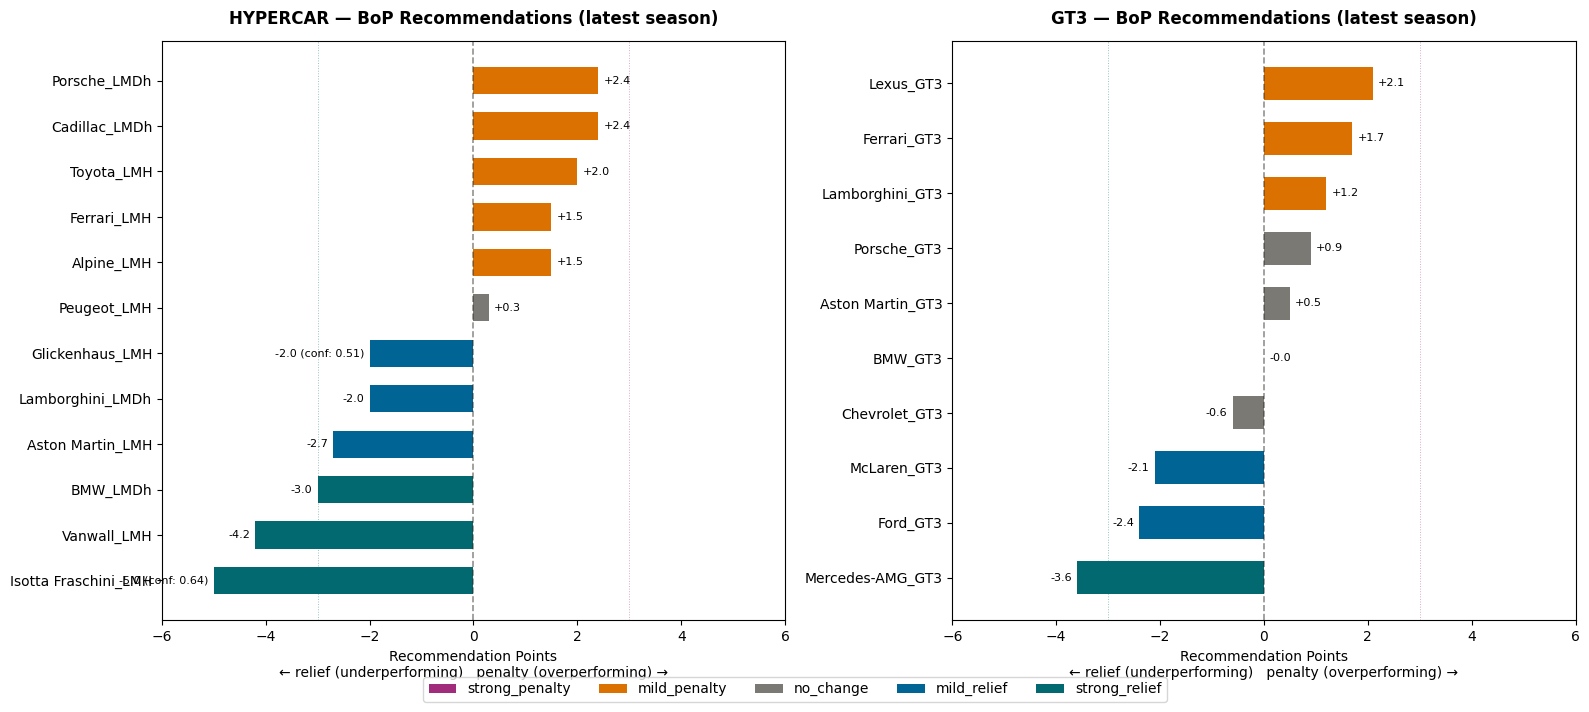

In [37]:
LABEL_COLORS = {
    'strong_penalty': '#a12c7b',
    'mild_penalty':   '#da7101',
    'no_change':      '#7a7974',
    'mild_relief':    '#006494',
    'strong_relief':  '#01696f',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, cls in zip(axes, ['HYPERCAR', 'GT3']):
    # Берём последний доступный год для каждой модели
    latest = (
        season_agg[season_agg['class_normalized'] == cls]
        .sort_values('year')
        .groupby('car_model_key')
        .last()
        .reset_index()
        .sort_values('recommendation_points')
    )

    colors = [LABEL_COLORS[l] for l in latest['recommendation_label']]
    bars = ax.barh(latest['car_model_key'], latest['recommendation_points'],
                   color=colors, height=0.6)

    ax.axvline(0, color='#28251d', linewidth=1.2, linestyle='--', alpha=0.5)
    ax.axvline(-3, color='#01696f', linewidth=0.7, linestyle=':', alpha=0.4)
    ax.axvline(3, color='#a12c7b', linewidth=0.7, linestyle=':', alpha=0.4)

    # Подписи значений + confidence
    for bar, (_, row) in zip(bars, latest.iterrows()):
        val = row['recommendation_points']
        conf = row['confidence_score']
        offset = 0.1 if val >= 0 else -0.1
        ha = 'left' if val >= 0 else 'right'
        label = f"{val:+.1f}"
        if conf < 0.8:
            label += f" (conf: {conf:.2f})"
        ax.text(val + offset, bar.get_y() + bar.get_height()/2,
                label, va='center', ha=ha, fontsize=8)

    ax.set_xlabel('Recommendation Points\n← relief (underperforming)   penalty (overperforming) →')
    ax.set_title(f'{cls} — BoP Recommendations (latest season)',
                 fontweight='bold', pad=12)
    ax.set_xlim(-6, 6)

# Легенда
legend_elements = [mpatches.Patch(facecolor=c, label=l)
                   for l, c in LABEL_COLORS.items()]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=5, bbox_to_anchor=(0.5, -0.02), framealpha=0.8)

plt.tight_layout()
plt.savefig('../reports/bop_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()

Auto POINT_TO_SEC = 0.127


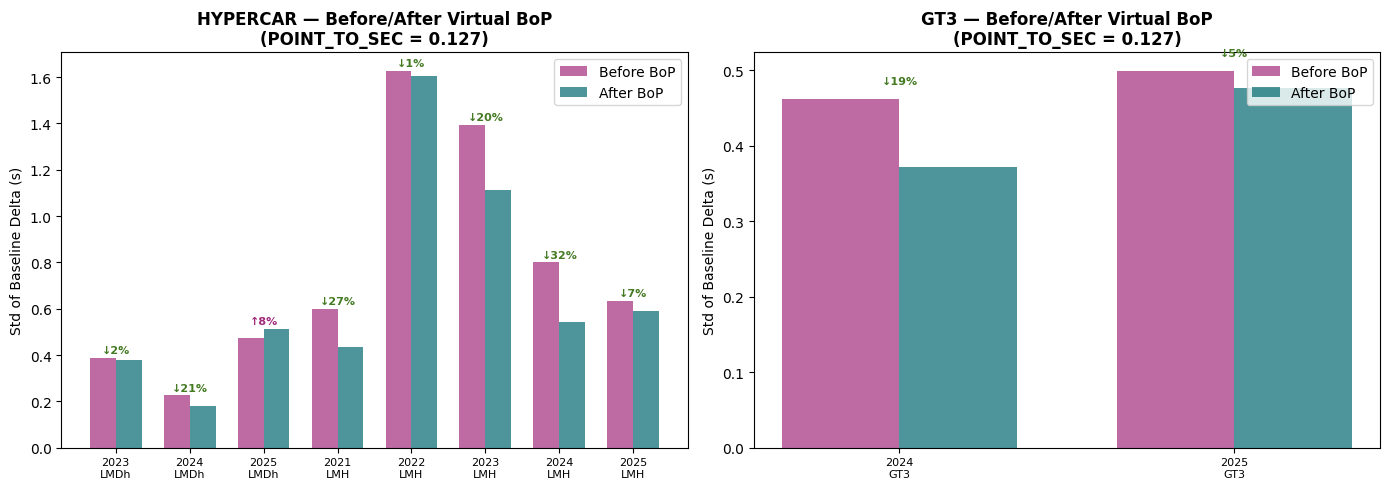

In [38]:
avg_delta_range = (
    event_model[event_model['class_normalized'].isin(['HYPERCAR', 'GT3'])]
    .groupby(['class_normalized', 'homologation_group'])['baseline_delta']
    .std().mean()
)
POINT_TO_SEC = round(avg_delta_range / 5, 3)
print(f"Auto POINT_TO_SEC = {POINT_TO_SEC}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cls in zip(axes, ['HYPERCAR', 'GT3']):
    # Работаем с median_clean_lap — абсолютные времена кругов
    subset = event_model[event_model['class_normalized'] == cls].copy()

    recs = season_agg[season_agg['class_normalized'] == cls][
        ['car_model_key', 'year', 'recommendation_points']
    ]
    subset = subset.merge(recs, on=['car_model_key', 'year'], how='left')

    # Корректировка: penalty → прибавляем секунды (замедляем)
    # relief → вычитаем секунды (ускоряем)
    # recommendation_points > 0 = penalty, < 0 = relief
    subset['adjusted_lap'] = (
        subset['median_clean_lap'] +
        subset['recommendation_points'] * POINT_TO_SEC
    )

    # Пересчитываем baseline_delta после корректировки
    grp_baseline_after = (
        subset.groupby(['year', 'homologation_group', 'event'])['adjusted_lap']
        .median()
        .rename('group_baseline_after')
        .reset_index()
    )
    subset = subset.merge(grp_baseline_after,
                          on=['year', 'homologation_group', 'event'], how='left')
    subset['adjusted_delta'] = subset['adjusted_lap'] - subset['group_baseline_after']

    # std до и после
    before = subset.groupby(['year', 'homologation_group'])['baseline_delta'].std()
    after  = subset.groupby(['year', 'homologation_group'])['adjusted_delta'].std()

    comparison = pd.DataFrame({'before': before, 'after': after}).reset_index()
    comparison['improvement'] = comparison['before'] - comparison['after']
    comparison['label'] = comparison['year'].astype(str) + '\n' + comparison['homologation_group']
    comparison = comparison.sort_values(['homologation_group', 'year'])

    x = np.arange(len(comparison))
    width = 0.35

    ax.bar(x - width/2, comparison['before'], width,
           label='Before BoP', color='#a12c7b', alpha=0.7)
    ax.bar(x + width/2, comparison['after'], width,
           label='After BoP', color='#01696f', alpha=0.7)

    for i, (_, row) in enumerate(comparison.iterrows()):
        pct = (row['improvement'] / row['before'] * 100) if row['before'] > 0 else 0
        color = '#437a22' if pct > 0 else '#a12c7b'
        sign = '↓' if pct > 0 else '↑'
        ax.text(i, max(row['before'], row['after']) + 0.02,
                f"{sign}{abs(pct):.0f}%",
                ha='center', fontsize=8, color=color, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(comparison['label'], fontsize=8)
    ax.set_ylabel('Std of Baseline Delta (s)')
    ax.set_title(f'{cls} — Before/After Virtual BoP\n(POINT_TO_SEC = {POINT_TO_SEC})',
                 fontweight='bold')
    ax.legend(framealpha=0.8)

plt.tight_layout()
plt.savefig('../reports/before_after_bop.png', dpi=150, bbox_inches='tight')
plt.show()

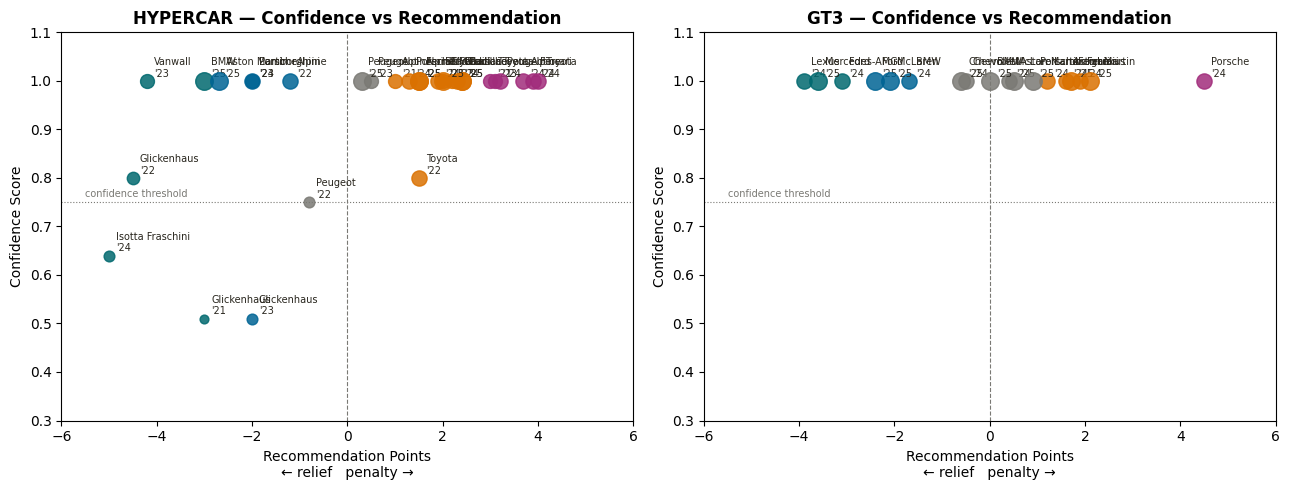

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cls in zip(axes, ['HYPERCAR', 'GT3']):
    subset = season_agg[season_agg['class_normalized'] == cls]

    for _, row in subset.iterrows():
        color = LABEL_COLORS[row['recommendation_label']]
        ax.scatter(row['recommendation_points'], row['confidence_score'],
                   s=row['events_count'] * 20,
                   color=color, alpha=0.85, zorder=3)
        ax.annotate(
            f"{row['manufacturer']}\n'{str(row['year'])[2:]}",
            xy=(row['recommendation_points'], row['confidence_score']),
            xytext=(5, 3), textcoords='offset points',
            fontsize=7, color='#28251d'
        )

    ax.axvline(0, color='#7a7974', linewidth=0.8, linestyle='--')
    ax.axhline(0.75, color='#7a7974', linewidth=0.8, linestyle=':')
    ax.text(-5.5, 0.76, 'confidence threshold', fontsize=7, color='#7a7974')
    ax.set_xlabel('Recommendation Points\n← relief   penalty →')
    ax.set_ylabel('Confidence Score')
    ax.set_title(f'{cls} — Confidence vs Recommendation', fontweight='bold')
    ax.set_xlim(-6, 6)
    ax.set_ylim(0.3, 1.1)

plt.tight_layout()
plt.savefig('../reports/confidence_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Выводы по BoP Recommender

### Методология

Weighted score рассчитан на основе 4 компонентов:
`pace (50%) + consistency (20%) + long_run (20%) + stability (10%)`.
Нормализация выполнена внутри группы `[year, class, homologation_group]`
для честного сравнения LMH vs LMDh отдельно.

### HYPERCAR — рекомендации 2025

| Модель | Points | Label | Confidence |
|--------|--------|-------|------------|
| Porsche LMDh | +2.4 | mild_penalty | 1.0 |
| Cadillac LMDh | +2.4 | mild_penalty | 1.0 |
| Toyota LMH | +2.0 | mild_penalty | 1.0 |
| Ferrari LMH | +1.5 | mild_penalty | 1.0 |
| BMW LMDh | -3.0 | strong_relief | 1.0 |
| Vanwall LMH | -4.2 | strong_relief | 1.0 |
| Isotta Fraschini LMH | -5.0 | strong_relief | 0.64 ⚠️ |

**Toyota и Ferrari** системно быстрее baseline на протяжении всего датасета.
**BMW LMDh** — дебютный сезон 2024, нуждается в облегчении для конкурентоспособности.

### GT3 — рекомендации 2025

Поле в пределах 0.6 секунды — BoP в LMGT3 работает эффективно.
**Mercedes-AMG (-3.6)** и **Ford (-2.4)** нуждаются в наибольшем облегчении.
**Lexus (+2.1)** и **Ferrari (+1.7)** — кандидаты на дополнительную нагрузку.

### Валидация — Before/After Virtual BoP

Применение виртуальных корректировок (POINT_TO_SEC = 0.127) показывает:
- **LMH 2024: -32% std** — наибольшее улучшение баланса в поле
- **LMH 2023: -20% std** — подтверждает корректность рекомендаций
- **GT3 2024: -19% std** — система работает и для GT3
- **LMDh 2025: +8% std** — поле уже сбалансировано, aggressive BoP избыточен

### Ограничения Recommender

- `POINT_TO_SEC = 0.127` — эмпирический коэффициент, требует калибровки
  на реальных исторических BoP изменениях от ACO/FIA
- Модели с `confidence < 0.75` (Glickenhaus, Isotta Fraschini) требуют
  осторожной интерпретации из-за малой выборки
- Recommender не учитывает конкретные трассовые характеристики
  (downforce setup, straight-line speed) — только темп и консистентность

